# Plot coordinates evolution for predicted sources

In [1]:
%matplotlib inline
#%matplotlib ipympl  # Interactive plots
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches
import matplotlib.collections as mcols
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.legend_handler import HandlerTuple
from astropy.visualization import LogStretch, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from itertools import combinations
from cmap import Colormap
import met_brewer
import pandas as pd
from os import path
import global_variables as gv
import global_functions as gf

In [2]:
mpl.rcdefaults()
plt.rcParams['text.usetex'] = True

In [3]:
def create_colours(df, mag_list, mag_names_short_ver):
    colours_list = []
    for mags_pair in combinations(mag_list, 2):
        colour_name = mag_names_short_ver[mags_pair[0]] + '_' + mag_names_short_ver[mags_pair[1]]
        df[colour_name] = df[mags_pair[0]] - df[mags_pair[1]]
        colours_list.append(colour_name)
    return df, colours_list

In [4]:
def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    """Shift colormap so 'midpoint' data value maps to colormap center."""
    cdict = {'red': [], 'green': [], 'blue': [], 'alpha': []}
    reg_index = np.linspace(start, stop, 257)
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False),
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])
    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)
        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))
    return mcolors.LinearSegmentedColormap(name, cdict)

In [5]:
def combine_predictions(df):
    pred_AGN_filter  = df['pred_class_cal'] == 1
    df['pred_radio'] = np.where(pred_AGN_filter, df['pred_radio_AGN_cal'], df['pred_radio_SFG_cal'])
    df['Prob_radio'] = np.where(pred_AGN_filter, df['Prob_radio_AGN'], df['Prob_radio_SFG'])
    df['pred_Z']     = np.where(pred_AGN_filter, df['pred_Z_rAGN'], df['pred_Z_rSFG'])
    return df

In [6]:
save_plots  = False

In [7]:
use_imputed = False  # use (or not) imputed magnitudes and colours
if use_imputed:
    imputed_str = 'imputed'
elif not use_imputed:
    imputed_str = 'nonimputed'

In [8]:
used_sample             = 'known'  # 'known', 'unknown'

In [9]:
file_HETDEX_known       = gv.preds_path + 'HETDEX_Test_prediction.parquet'
file_HETDEX_unknown     = gv.preds_path + 'HETDEX_Unknown_prediction.parquet'
files_HETDEX            = {'known': file_HETDEX_known, 'unknown': file_HETDEX_unknown}

In [10]:
file_HETDEX_nonimp_mags = gv.preds_path + 'HETDEX_mags_non_imputed.parquet'

In [11]:
data_catalog_HETDEX_df  = pd.read_parquet(files_HETDEX[used_sample], engine='fastparquet')

In [12]:
data_nonimp_mags        = pd.read_parquet(file_HETDEX_nonimp_mags, engine='fastparquet')

Replace mags with non-imp versions

In [13]:
data_idx  = data_catalog_HETDEX_df.index
mags_cols = data_nonimp_mags.columns
data_catalog_HETDEX_df.loc[data_idx, mags_cols] = data_nonimp_mags.loc[data_idx, mags_cols]

Re-calculate colours with non-imp magnitudes

In [14]:
mag_names_short      = {'gmag': 'g', 'rmag': 'r', 'imag': 'i', 'zmag': 'z',
                        'ymag': 'y', 'Jmag': 'J', 'Hmag': 'H', 'Kmag': 'K',
                        'W1mproPM': 'W1', 'W2mproPM': 'W2',
                        'W3mag': 'W3', 'W4mag': 'W4'}

In [15]:
data_catalog_HETDEX_df, colours_list = create_colours(data_catalog_HETDEX_df,mags_cols, mag_names_short)

In [16]:
# np.array(data_catalog_HETDEX_df.columns)

In [17]:
data_catalog_HETDEX_df            = combine_predictions(data_catalog_HETDEX_df)
data_catalog_HETDEX_df['log_z']   = np.log10(data_catalog_HETDEX_df['pred_Z'])
data_catalog_HETDEX_df['log1p_z'] = np.log10(1 + data_catalog_HETDEX_df['pred_Z'])

In [18]:
true_radio_filter = data_catalog_HETDEX_df.loc[:, 'radio_detect'] == 1
pred_radio_filter = data_catalog_HETDEX_df.loc[:, 'pred_radio'] == 1
true_AGN_filter   = data_catalog_HETDEX_df.loc[:, 'class'] == 1
true_nAGN_filter  = data_catalog_HETDEX_df.loc[:, 'class'] == 0
pred_AGN_filter   = data_catalog_HETDEX_df.loc[:, 'pred_class_cal'] == 1

In [19]:
used_cols_plt = ['J_H', 'z_y', 'W4mag', 'W3_W4', 'H_K', 'H_W3', 'y_J',
                 'i_y', 'z_W2', 'band_num', 'i_z', 'y_W2', 'r_J', 'W1_W3',
                 'r_i', 'g_r', 'W1_W2', 'y_W1', 'Prob_AGN'] +\
                ['J_H', 'H_K', 'W4mag', 'Kmag', 'z_y', 'i_z', 'r_i',
                 'i_y', 'g_r', 'r_y', 'y_J', 'H_W3', 'g_W2', 'y_W2',
                 'z_W2', 'W1_W2', 'W3_W4', 'W1_W3', 'Prob_radio'] +\
                ['J_H', 'H_K', 'K_W4', 'band_num', 'W4mag', 'y_W1', 'z_y',
                 'i_z', 'r_z', 'r_i', 'z_W1', 'W1_W2', 'K_W3', 'y_J',
                 'g_r', 'W2_W3', 'g_i', 'Prob_radio'] +\
                ['J_H', 'W4mag', 'i_z', 'z_y', 'W1_W3', 'i_y', 'r_i',
                 'y_W2', 'K_W3', 'W1_W2', 'r_z', 'g_r', 'H_K', 'y_J', 'log1p_z'] +\
                ['J_H', 'K_W4', 'K_W3', 'g_W3', 'W4mag', 'i_z', 'H_K',
                  'i_y', 'band_num', 'y_J', 'z_y', 'r_z', 'r_i', 'W1_W2',
                  'W2_W3', 'y_W1', 'g_r', 'pred_Z']

In [20]:
np.unique(used_cols_plt)

array(['H_K', 'H_W3', 'J_H', 'K_W3', 'K_W4', 'Kmag', 'Prob_AGN',
       'Prob_radio', 'W1_W2', 'W1_W3', 'W2_W3', 'W3_W4', 'W4mag',
       'band_num', 'g_W2', 'g_W3', 'g_i', 'g_r', 'i_y', 'i_z', 'log1p_z',
       'pred_Z', 'r_J', 'r_i', 'r_y', 'r_z', 'y_J', 'y_W1', 'y_W2',
       'z_W1', 'z_W2', 'z_y'], dtype='<U10')

In [21]:
feats_names_strs = {'H_K': r'${H} - {Ks}$', 'H_W3': r'${H} - {W3}$',
                    'J_H': r'${J} - {H}$', 'K_W3': r'${Ks} - {W3}$',
                    'K_W4': r'${Ks} - {W4}$', 'W1_W2': r'${W1} - {W2}$',
                    'W1_W3': r'${W1} - {W3}$', 'W2_W3': r'${W2} - {W3}$',
                    'W3_W4': r'${W3} - {W4}$', 'g_W2': r'${g} - {W2}$',
                    'g_W3': r'${g} - {W3}$', 'g_i': r'${g} - {i}$',
                    'g_r': r'${g} - {r}$', 'i_y': r'${i} - {y}$',
                    'i_z': r'${i} - {z}$', 'r_J': r'${r} - {J}$',
                    'r_i': r'${r} - {i}$', 'r_y': r'${r} - {y}$',
                    'r_z': r'${r} - {z}$', 'y_J': r'${y} - {J}$',
                    'y_W1': r'${y} - {W1}$', 'y_W2': r'${y} - {W2}$',
                    'z_W1': r'${z} - {W1}$', 'z_W2': r'${z} - {W2}$',
                    'z_y': r'${z} - {y}$',
                    'Kmag': r'${Ks}$', 'W4mag': r'${W4}$',
                    'band_num': r'$\mathtt{band\_num}$',
                    'Prob_AGN': r'$p(\mathrm{AGN})$',
                    'Prob_radio': r'$p(\mathrm{radio}\vert \mathrm{non{-}AGN})$',
                    'pred_Z': r'$\mathrm{predicted ~ redshift}$',
                    'log1p_z': r'$1 + z_{\mathrm{pred}}$',
                    '': ''}

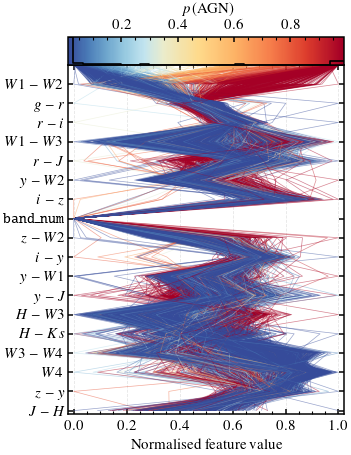

In [24]:
cols_2_plot   = ['J_H', 'z_y', 'W4mag', 'W3_W4', 'H_K', 'H_W3', 'y_J',
                 'y_W1', 'i_y', 'z_W2', 'band_num', 'i_z', 'y_W2',
                 'r_J', 'W1_W3', 'r_i', 'g_r', 'W1_W2', 'Prob_AGN']  # z prediction for radio non-AGN
colour_col    = ['Prob_AGN']
y_labels      = cols_2_plot[:-1] + ['']
y_labels      = [feats_names_strs[y_label] for y_label in y_labels]

base          = data_catalog_HETDEX_df.loc[:, cols_2_plot]
base          = base.dropna(subset=cols_2_plot)  # remove rows with NaNs in colours

# Sample the same 10% of rows
used_filter   = true_AGN_filter | true_nAGN_filter
# used_filter   = true_radio_filter & true_nAGN_filter
keep_idx      = base.loc[used_filter, cols_2_plot[0]].sample(frac=1.0, random_state=42).index
data          = base.loc[keep_idx, cols_2_plot].to_numpy()
color_by      = base.loc[keep_idx, colour_col].to_numpy()

n_obj, n_feat = data.shape
y             = np.arange(n_feat)

# Vectorized per-feature min-max normalization
mins          = np.nanmin(data, axis=0)
maxs          = np.nanmax(data, axis=0)
ranges        = np.where(maxs > mins, maxs - mins, 1.0)
data_norm     = (data - mins) / ranges

# Build segments array for LineCollection: shape (n_obj, n_feat, 2)
# Each segment is the polyline of one object.
x             = data_norm  # shape (n_obj, n_feat)
yy            = np.broadcast_to(y, (n_obj, n_feat))
segments      = np.stack([x, yy], axis=2)  # (n_obj, n_feat, 2)

# Colors from third variable
cmap_original = Colormap('tol:sunset').to_mpl(N=256) # 'tol:sunset' 'paraview:fast'
thresh_norm   = (gv.cal_AGN_thresh - np.nanmin(color_by)) / (np.nanmax(color_by) - np.nanmin(color_by))
cmap_shifted  = shiftedColorMap(cmap_original, midpoint=thresh_norm)
norm          = mcolors.Normalize(vmin=np.nanmin(color_by), vmax=np.nanmax(color_by))
colors        = cmap_shifted(norm(color_by))

base_size, rc_tmp = gf.set_aaasize('column', aspect=1.3, fraction=1.0)  # 'text' or 'column'
with mpl.rc_context(rc_tmp):
    fig, ax = plt.subplots(figsize=base_size, layout='compressed')
    
    lc = mcols.LineCollection(segments,
                              colors=colors,
                              linewidths=0.5,
                              alpha=0.5)
    ax.add_collection(lc)
    
    ax.set_xlim(left=-0.02, right=1.02)
    ax.set_ylim(bottom=y.min() - 0.2, top=y.max())
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel(r'$\mathrm{Normalised ~ feature ~ value}$')
    ax.tick_params(axis='y', which='minor', right=False, left=False)
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_shifted),
                        ax=ax, 
                        orientation='horizontal', 
                        pad=0,  # distance from top
                        aspect=10,  # makes it longer/thinner
                        location='top')
    cbar.set_label(feats_names_strs[colour_col[0]])

    # Add histogram to colourbar
    # After creating cbar and norm
    cbar_min = norm.vmin
    cbar_max = norm.vmax
    
    # Histogram in data (z) space
    hist_vals, bin_edges = np.histogram(
        color_by,
        bins=np.linspace(cbar_min, cbar_max, 30)
    )
    
    ymin_cb, ymax_cb = cbar.ax.get_ylim()
    available_height = (ymax_cb - ymin_cb) * 0.9
    scaled_hist      = hist_vals / np.max(hist_vals) * available_height
    
    ax_hist          = cbar.ax.twiny()
    ax_hist.set_xlim(cbar_min, cbar_max)
    ax_hist.set_ylim(0, available_height)
    #ax_hist.plot(bin_edges[:-1], scaled_hist, drawstyle='steps-mid',
    #             color='black', linewidth=1.2)
    ax_hist.plot(bin_edges, np.r_[scaled_hist, scaled_hist[-1]],
                 drawstyle='steps-mid', color='black', linewidth=1.2)
    ax_hist.axis('off')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax.grid(axis='x', alpha=0.1, ls='--', c='k')
    if save_plots:
        plt.savefig(gv.plots_path + 'parallel_coords_AGN_prob_HETDEX.pdf', bbox_inches='tight')
    plt.show()

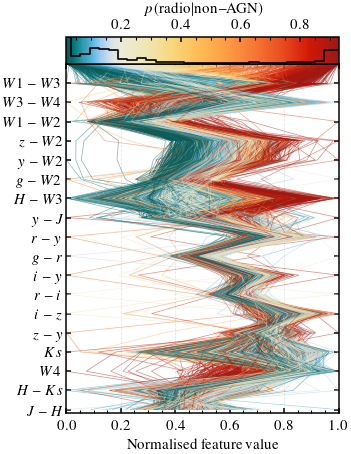

In [23]:
cols_2_plot   = ['J_H', 'H_K', 'W4mag', 'Kmag', 'z_y', 'i_z', 'r_i',
                 'i_y', 'g_r', 'r_y', 'y_J', 'H_W3', 'g_W2', 'y_W2',
                 'z_W2', 'W1_W2', 'W3_W4', 'W1_W3', 'Prob_radio']  # z prediction for radio non-AGN
colour_col    = ['Prob_radio']
y_labels      = cols_2_plot[:-1] + ['']
y_labels      = [feats_names_strs[y_label] for y_label in y_labels]

base          = data_catalog_HETDEX_df.loc[:, cols_2_plot]
base          = base.dropna(subset=cols_2_plot)  # remove rows with NaNs in colours

# Sample the same 10% of rows
used_filter   = true_nAGN_filter
# used_filter   = true_radio_filter & true_nAGN_filter
keep_idx      = base.loc[used_filter, cols_2_plot[0]].sample(frac=1.0, random_state=42).index
data          = base.loc[keep_idx, cols_2_plot].to_numpy()
color_by      = base.loc[keep_idx, colour_col].to_numpy()

n_obj, n_feat = data.shape
y             = np.arange(n_feat)

# Vectorized per-feature min-max normalization
mins          = np.nanmin(data, axis=0)
maxs          = np.nanmax(data, axis=0)
ranges        = np.where(maxs > mins, maxs - mins, 1.0)
data_norm     = (data - mins) / ranges

# Build segments array for LineCollection: shape (n_obj, n_feat, 2)
# Each segment is the polyline of one object.
x             = data_norm  # shape (n_obj, n_feat)
yy            = np.broadcast_to(y, (n_obj, n_feat))
segments      = np.stack([x, yy], axis=2)  # (n_obj, n_feat, 2)

# Colors from third variable
cmap_original = Colormap('tol:nightfall').to_mpl(N=256)  # 'tol:nightfall'
thresh_norm   = (gv.cal_radio_gals_thresh - np.nanmin(color_by)) / (np.nanmax(color_by) - np.nanmin(color_by))
cmap_shifted  = shiftedColorMap(cmap_original, midpoint=thresh_norm)
norm          = mcolors.Normalize(vmin=np.nanmin(color_by), vmax=np.nanmax(color_by))
colors        = cmap_shifted(norm(color_by))

base_size, rc_tmp = gf.set_aaasize('column', aspect=1.3, fraction=1.0)  # 'text' or 'column'
with mpl.rc_context(rc_tmp):
    fig, ax = plt.subplots(figsize=base_size, layout='compressed')
    
    lc = mcols.LineCollection(segments,
                              colors=colors,
                              linewidths=0.5,
                              alpha=0.5)
    ax.add_collection(lc)
    
    #ax.set_xlim(left=-0.02, right=1.02)
    ax.set_ylim(bottom=y.min() - 0.2, top=y.max())
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel(r'$\mathrm{Normalised ~ feature ~ value}$')
    ax.tick_params(axis='y', which='minor', right=False, left=False)
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_shifted),
                        ax=ax, 
                        orientation='horizontal', 
                        pad=0,  # distance from top
                        aspect=10,  # makes it longer/thinner
                        location='top')
    cbar.set_label(feats_names_strs[colour_col[0]])

    # Add histogram to colourbar
    # After creating cbar and norm
    cbar_min = norm.vmin
    cbar_max = norm.vmax
    
    # Histogram in data (z) space
    hist_vals, bin_edges = np.histogram(
        color_by,
        bins=np.linspace(cbar_min, cbar_max, 30)
    )
    
    ymin_cb, ymax_cb = cbar.ax.get_ylim()
    available_height = (ymax_cb - ymin_cb) * 0.9
    scaled_hist      = hist_vals / np.max(hist_vals) * available_height
    
    ax_hist          = cbar.ax.twiny()
    ax_hist.set_xlim(cbar_min, cbar_max)
    ax_hist.set_ylim(0, available_height)
    #ax_hist.plot(bin_edges[:-1], scaled_hist, drawstyle='steps-mid',
    #             color='black', linewidth=1.2)
    ax_hist.plot(bin_edges, np.r_[scaled_hist, scaled_hist[-1]],
                 drawstyle='steps-mid', color='black', linewidth=1.2)
    ax_hist.axis('off')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax.grid(axis='x', alpha=0.1, ls='--', c='k')
    if save_plots:
        plt.savefig(gv.plots_path + 'parallel_coords_radio_prob_non_AGN_HETDEX.pdf', bbox_inches='tight')
    plt.show()

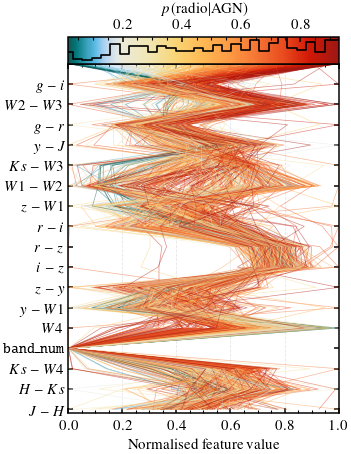

In [30]:
cols_2_plot   = ['J_H', 'H_K', 'K_W4', 'band_num', 'W4mag', 'y_W1', 'z_y',
                 'i_z', 'r_z', 'r_i', 'z_W1', 'W1_W2', 'K_W3', 'y_J',
                 'g_r', 'W2_W3', 'g_i', 'Prob_radio']  # z prediction for radio non-AGN
colour_col    = ['Prob_radio']
y_labels      = cols_2_plot[:-1] + ['']
y_labels      = [feats_names_strs[y_label] for y_label in y_labels]

base          = data_catalog_HETDEX_df.loc[:, cols_2_plot]
base          = base.dropna(subset=cols_2_plot)  # remove rows with NaNs in colours

# Sample the same 10% of rows
used_filter   = true_AGN_filter
# used_filter   = true_radio_filter & true_nAGN_filter
keep_idx      = base.loc[used_filter, cols_2_plot[0]].sample(frac=1.0, random_state=42).index
data          = base.loc[keep_idx, cols_2_plot].to_numpy()
color_by      = base.loc[keep_idx, colour_col].to_numpy()

n_obj, n_feat = data.shape
y             = np.arange(n_feat)

# Vectorized per-feature min-max normalization
mins          = np.nanmin(data, axis=0)
maxs          = np.nanmax(data, axis=0)
ranges        = np.where(maxs > mins, maxs - mins, 1.0)
data_norm     = (data - mins) / ranges

# Build segments array for LineCollection: shape (n_obj, n_feat, 2)
# Each segment is the polyline of one object.
x             = data_norm  # shape (n_obj, n_feat)
yy            = np.broadcast_to(y, (n_obj, n_feat))
segments      = np.stack([x, yy], axis=2)  # (n_obj, n_feat, 2)

# Colors from third variable
cmap_original = Colormap('tol:nightfall').to_mpl(N=256)  # 'tol:nightfall'
thresh_norm   = (gv.cal_radio_gals_thresh - np.nanmin(color_by)) / (np.nanmax(color_by) - np.nanmin(color_by))
cmap_shifted  = shiftedColorMap(cmap_original, midpoint=thresh_norm)
norm          = mcolors.Normalize(vmin=np.nanmin(color_by), vmax=np.nanmax(color_by))
colors        = cmap_shifted(norm(color_by))

base_size, rc_tmp = gf.set_aaasize('column', aspect=1.3, fraction=1.0)  # 'text' or 'column'
with mpl.rc_context(rc_tmp):
    fig, ax = plt.subplots(figsize=base_size, layout='compressed')
    
    lc = mcols.LineCollection(segments,
                              colors=colors,
                              linewidths=0.5,
                              alpha=0.5)
    ax.add_collection(lc)
    
    #ax.set_xlim(left=-0.02, right=1.02)
    ax.set_ylim(bottom=y.min() - 0.2, top=y.max())
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel(r'$\mathrm{Normalised ~ feature ~ value}$')
    ax.tick_params(axis='y', which='minor', right=False, left=False)
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_shifted),
                        ax=ax, 
                        orientation='horizontal', 
                        pad=0,  # distance from top
                        aspect=10,  # makes it longer/thinner
                        location='top')
    #cbar.set_label(feats_names_strs[colour_col[0]])
    cbar.set_label(r'$p(\mathrm{radio}\vert \mathrm{AGN})$')

    # Add histogram to colourbar
    # After creating cbar and norm
    cbar_min = norm.vmin
    cbar_max = norm.vmax
    
    # Histogram in data (z) space
    hist_vals, bin_edges = np.histogram(
        color_by,
        bins=np.linspace(cbar_min, cbar_max, 30)
    )
    
    ymin_cb, ymax_cb = cbar.ax.get_ylim()
    available_height = (ymax_cb - ymin_cb) * 0.9
    scaled_hist      = hist_vals / np.max(hist_vals) * available_height
    
    ax_hist          = cbar.ax.twiny()
    ax_hist.set_xlim(cbar_min, cbar_max)
    ax_hist.set_ylim(0, available_height)
    #ax_hist.plot(bin_edges[:-1], scaled_hist, drawstyle='steps-mid',
    #             color='black', linewidth=1.2)
    ax_hist.plot(bin_edges, np.r_[scaled_hist, scaled_hist[-1]],
                 drawstyle='steps-mid', color='black', linewidth=1.2)
    ax_hist.axis('off')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax.grid(axis='x', alpha=0.1, ls='--', c='k')
    if save_plots:
        plt.savefig(gv.plots_path + 'parallel_coords_radio_prob_AGN_HETDEX.pdf', bbox_inches='tight')
    plt.show()

In [25]:
def fmt_orig_redshift(x, pos):
        return rf'${x - 1:.1f}$'

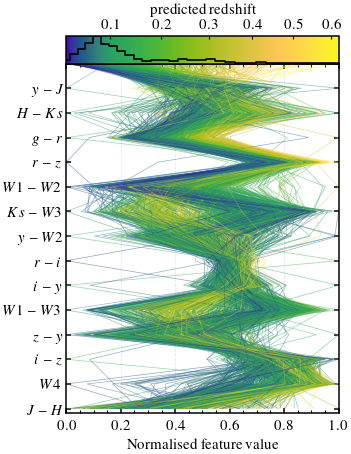

In [26]:
cols_2_plot    = ['J_H', 'W4mag', 'i_z', 'z_y', 'W1_W3', 'i_y',
                  'r_i', 'y_W2', 'K_W3', 'W1_W2', 'r_z',
                  'g_r', 'H_K', 'y_J', 'pred_Z']  # z prediction for radio non-AGN
colour_col     = ['pred_Z']
y_labels       = cols_2_plot[:-1] + ['']
y_labels       = [feats_names_strs[y_label] for y_label in y_labels]

base           = data_catalog_HETDEX_df.loc[:, cols_2_plot]
base           = base.dropna(subset=cols_2_plot)  # remove rows with NaNs in colours

# Sample the same 10% of rows
used_filter   = pred_radio_filter & ~pred_AGN_filter
# used_filter   = true_radio_filter & true_nAGN_filter
keep_idx      = base.loc[used_filter, cols_2_plot[0]].sample(frac=1.0, random_state=42).index
data          = base.loc[keep_idx, cols_2_plot].to_numpy()
color_by      = 1 + base.loc[keep_idx, colour_col].to_numpy() # use 1+z for LogNorm

n_obj, n_feat = data.shape
y             = np.arange(n_feat)

# Vectorized per-feature min-max normalization
mins          = np.nanmin(data, axis=0)
maxs          = np.nanmax(data, axis=0)
ranges        = np.where(maxs > mins, maxs - mins, 1.0)
data_norm     = (data - mins) / ranges

# Build segments array for LineCollection: shape (n_obj, n_feat, 2)
# Each segment is the polyline of one object.
x             = data_norm  # shape (n_obj, n_feat)
yy            = np.broadcast_to(y, (n_obj, n_feat))
segments      = np.stack([x, yy], axis=2)  # (n_obj, n_feat, 2)

# Colors from third variable
cmap_original = Colormap('bids:fake_parula').to_mpl(N=256) # 'bids:fake_parula'
thresh_norm   = (np.nanmedian(color_by) - np.nanmin(color_by)) / (np.nanmax(color_by) - np.nanmin(color_by))
cmap_shifted  = shiftedColorMap(cmap_original, midpoint=thresh_norm)
norm          = mcolors.LogNorm(vmin=np.nanmin(color_by), vmax=np.nanmax(color_by))
colors        = cmap_shifted(norm(color_by))

base_size, rc_tmp = gf.set_aaasize('column', aspect=1.3, fraction=1.0)  # 'text' or 'column'
with mpl.rc_context(rc_tmp):
    fig, ax = plt.subplots(figsize=base_size, layout='compressed')
    
    lc = mcols.LineCollection(segments,
                              colors=colors,
                              linewidths=0.5,
                              alpha=0.5)
    ax.add_collection(lc)
    
    #ax.set_xlim(left=-0.02, right=1.02)
    ax.set_ylim(bottom=y.min() - 0.2, top=y.max())
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel(r'$\mathrm{Normalised ~ feature ~ value}$')
    ax.tick_params(axis='y', which='minor', right=False, left=False)
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_shifted),
                        ax=ax, 
                        orientation='horizontal', 
                        pad=0,  # distance from top
                        aspect=10,  # makes it longer/thinner
                        location='top')
    cbar.set_label(feats_names_strs[colour_col[0]])
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_orig_redshift))
    cbar.ax.xaxis.set_minor_formatter(mticker.FuncFormatter(fmt_orig_redshift))

    # Add histogram to colourbar
    # After creating cbar and norm
    cbar_min = norm.vmin
    cbar_max = norm.vmax
    
    # Histogram in data (z) space
    hist_vals, bin_edges = np.histogram(
        color_by,
        bins=np.logspace(np.log10(cbar_min), np.log10(cbar_max), 30)
    )
    
    ymin_cb, ymax_cb = cbar.ax.get_ylim()
    available_height = (ymax_cb - ymin_cb) * 0.9
    scaled_hist      = hist_vals / np.max(hist_vals) * available_height
    
    ax_hist          = cbar.ax.twiny()
    ax_hist.set_xlim(cbar_min, cbar_max)
    ax_hist.set_ylim(0, available_height)
    ax_hist.plot(bin_edges, np.r_[scaled_hist, scaled_hist[-1]],
                 drawstyle='steps-mid', color='black', linewidth=1.2)
    ax_hist.axis('off')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax.grid(axis='x', alpha=0.1, ls='--', c='k')
    if save_plots:
        plt.savefig(gv.plots_path + 'parallel_coords_z_radio_non_AGN_HETDEX.pdf', bbox_inches='tight')
    plt.show()

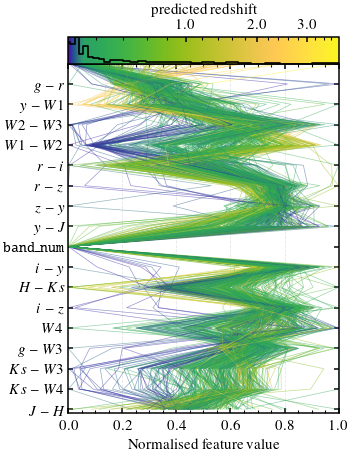

In [27]:
cols_2_plot    = ['J_H', 'K_W4', 'K_W3', 'g_W3', 'W4mag', 'i_z', 'H_K',
                  'i_y', 'band_num', 'y_J', 'z_y', 'r_z', 'r_i', 'W1_W2',
                  'W2_W3', 'y_W1', 'g_r', 'pred_Z']  # z prediction for radio non-AGN
colour_col     = ['pred_Z']
y_labels       = cols_2_plot[:-1] + ['']
y_labels       = [feats_names_strs[y_label] for y_label in y_labels]

base           = data_catalog_HETDEX_df.loc[:, cols_2_plot]
base           = base.dropna(subset=cols_2_plot)  # remove rows with NaNs in colours

# Sample the same 10% of rows
used_filter   = pred_radio_filter & pred_AGN_filter
# used_filter   = true_radio_filter & true_nAGN_filter
keep_idx      = base.loc[used_filter, cols_2_plot[0]].sample(frac=1.0, random_state=42).index
data          = base.loc[keep_idx, cols_2_plot].to_numpy()
color_by      = 1 + base.loc[keep_idx, colour_col].to_numpy() # use 1+z for LogNorm

n_obj, n_feat = data.shape
y             = np.arange(n_feat)

# Vectorized per-feature min-max normalization
mins          = np.nanmin(data, axis=0)
maxs          = np.nanmax(data, axis=0)
ranges        = np.where(maxs > mins, maxs - mins, 1.0)
data_norm     = (data - mins) / ranges

# Build segments array for LineCollection: shape (n_obj, n_feat, 2)
# Each segment is the polyline of one object.
x             = data_norm  # shape (n_obj, n_feat)
yy            = np.broadcast_to(y, (n_obj, n_feat))
segments      = np.stack([x, yy], axis=2)  # (n_obj, n_feat, 2)

# Colors from third variable
cmap_original = Colormap('bids:fake_parula').to_mpl(N=256) # 'bids:fake_parula'
thresh_norm   = (np.nanmedian(color_by) - np.nanmin(color_by)) / (np.nanmax(color_by) - np.nanmin(color_by))
cmap_shifted  = shiftedColorMap(cmap_original, midpoint=thresh_norm)
norm          = mcolors.LogNorm(vmin=np.nanmin(color_by), vmax=np.nanmax(color_by))
colors        = cmap_shifted(norm(color_by))

base_size, rc_tmp = gf.set_aaasize('column', aspect=1.3, fraction=1.0)  # 'text' or 'column'
with mpl.rc_context(rc_tmp):
    fig, ax = plt.subplots(figsize=base_size, layout='compressed')
    
    lc = mcols.LineCollection(segments,
                              colors=colors,
                              linewidths=0.5,
                              alpha=0.5)
    ax.add_collection(lc)
    
    #ax.set_xlim(left=-0.02, right=1.02)
    ax.set_ylim(bottom=y.min() - 0.2, top=y.max())
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel(r'$\mathrm{Normalised ~ feature ~ value}$')
    ax.tick_params(axis='y', which='minor', right=False, left=False)
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap_shifted),
                        ax=ax, 
                        orientation='horizontal', 
                        pad=0,  # distance from top
                        aspect=10,  # makes it longer/thinner
                        location='top')
    cbar.set_label(feats_names_strs[colour_col[0]])
    cbar.ax.minorticks_on()
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_orig_redshift))
    cbar.ax.xaxis.set_minor_formatter(mticker.FuncFormatter(fmt_orig_redshift))
    minor_ticks = np.concatenate([np.arange(n + 0.2, n + 0.9, 0.2) for n in range(1, 5)])
    cbar.ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    cbar.ax.xaxis.set_minor_locator(mticker.FixedLocator(minor_ticks))
    cbar.ax.xaxis.set_minor_formatter(plt.NullFormatter())

    # Add histogram to colourbar
    # After creating cbar and norm
    cbar_min = norm.vmin
    cbar_max = norm.vmax
    
    # Histogram in data (z) space
    hist_vals, bin_edges = np.histogram(
        color_by,
        bins=np.logspace(np.log10(cbar_min), np.log10(cbar_max), 30)
    )
    
    ymin_cb, ymax_cb = cbar.ax.get_ylim()
    available_height = (ymax_cb - ymin_cb) * 0.9
    scaled_hist      = hist_vals / np.max(hist_vals) * available_height
    
    ax_hist          = cbar.ax.twiny()
    ax_hist.set_xlim(cbar_min, cbar_max)
    ax_hist.set_ylim(0, available_height)
    ax_hist.plot(bin_edges, np.r_[scaled_hist, scaled_hist[-1]],
                 drawstyle='steps-mid', color='black', linewidth=1.2)
    ax_hist.axis('off')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax.grid(axis='x', alpha=0.1, ls='--', c='k')
    if save_plots:
        plt.savefig(gv.plots_path + 'parallel_coords_z_radio_AGN_HETDEX.pdf', bbox_inches='tight')
    plt.show()